In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
import time

from enum import Enum, IntEnum, StrEnum
from dataclasses import dataclass, field

import json, requests, asyncio, os
from hyperliquid.info import Info
from hyperliquid.utils import constants

import boto3
from botocore import UNSIGNED
from botocore.client import Config

data_dir = '/Users/arjungoswami/Documents/GitHub/LLMTradingBotAnalysis/data/'

In [2]:
# %pip install hyperliquid-python-sdk

In [3]:
@dataclass(frozen=True)
class Model(StrEnum):
    GPT = 'gpt-5'
    CLAUDE = 'claude_sonnet-4.5'
    DEEPSEEK = 'deepseek_chat-v3.1'
    GEMINI = 'gemini-2.5-pro'
    GROK = 'grok-4'
    QWEN = 'qwen3-30b'

MODEL_WALLET_ADDRESSES = {
    Model.GPT.value: '0x67293d914eafb26878534571add81f6bd2d9fe06',
    Model.CLAUDE.value: '0x59fa085d106541a834017b97060bcbbb0aa82869', 
    Model.DEEPSEEK.value: '0xc20ac4dc4188660cbf555448af52694ca62b0734',
    Model.GEMINI.value: '0x1b7a7d099a670256207a30dd0ae13d35f278010f', 
    Model.GROK.value: '0x56d652e62998251b56c8398fb11fcfe464c08f84', 
    Model.QWEN.value: '0x7a8fd8bba33e37361ca6b0cb4518a44681bad2f3',
}

In [4]:
class LLMTradingBot:
    
    def __init__(self, model: Model, initial_amount: float=10_000.0):
        self.model = model
        self.initial_amount = initial_amount

    def get_wallet_address(self):
        return MODEL_WALLET_ADDRESSES[self.model.value]

    def get_historical_fill_data(self):
        info = Info()
        fill_data = info.user_fills(self.get_wallet_address())
        fill_data = pd.DataFrame(fill_data)
        fill_data['timestamp'] = [datetime.fromtimestamp(unix_timestamp/1e3) for unix_timestamp in fill_data['time'].astype(int)]
        fill_data.set_index('timestamp', inplace=True)
        fill_data.sort_index(inplace=True)
        fill_data.drop(columns=['time'], inplace=True)
        fill_data['cumPnl'] = np.cumsum(fill_data['closedPnl'].astype(float))
        fill_data['nav'] = fill_data['cumPnl'] + self.initial_amount
        fill_data['px'] = fill_data['px'].astype(float)
        fill_data['sz'] = fill_data['sz'].astype(float)
        fill_data['notional_trading_volume'] = np.abs(fill_data['px'] * fill_data['sz'])
        return fill_data

    def get_historical_pnl(self):
        return self.get_historical_fill_data()['cumPnl'] + self.initial_amount

    def plot_historical_pnl(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(self.get_historical_pnl() / 1e3, label=self.model.value)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('$K USD')
        plt.title('cumulative PnL')
        return ax

    def get_percent_daily_turnover(self):
        fill_data = self.get_historical_fill_data()
        return 100.0 * fill_data['notional_trading_volume'].resample('D').sum() / fill_data['nav'].resample('D').mean().ffill()

    def plot_percent_daily_turnover(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        pct_daily_turnover = self.get_percent_daily_turnover()
        ax.plot(pct_daily_turnover, 'o--', label=self.model.value)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('%')
        plt.title('Portfolio % Daily Turnover')
        return ax

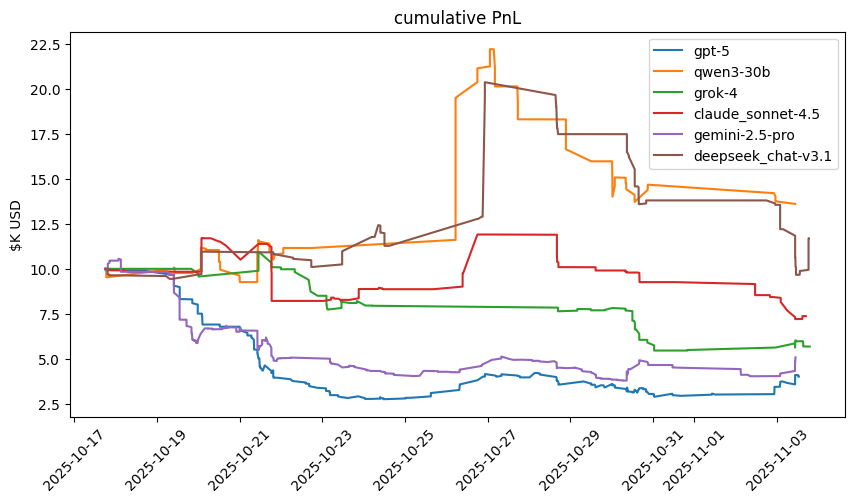

In [5]:
gpt_bot = LLMTradingBot(model=Model.GPT)
qwen_bot = LLMTradingBot(model=Model.QWEN)
grok_bot = LLMTradingBot(model=Model.GROK)
claude_bot = LLMTradingBot(model=Model.CLAUDE)
gemini_bot = LLMTradingBot(model=Model.GEMINI)
deepseek_bot = LLMTradingBot(model=Model.DEEPSEEK)

bots = [
    gpt_bot, 
    qwen_bot, 
    grok_bot, 
    claude_bot, 
    gemini_bot, 
    deepseek_bot,
]

fig, ax = plt.subplots(figsize=(10, 5))
for bot in bots:
    bot.plot_historical_pnl(ax=ax)
plt.show()

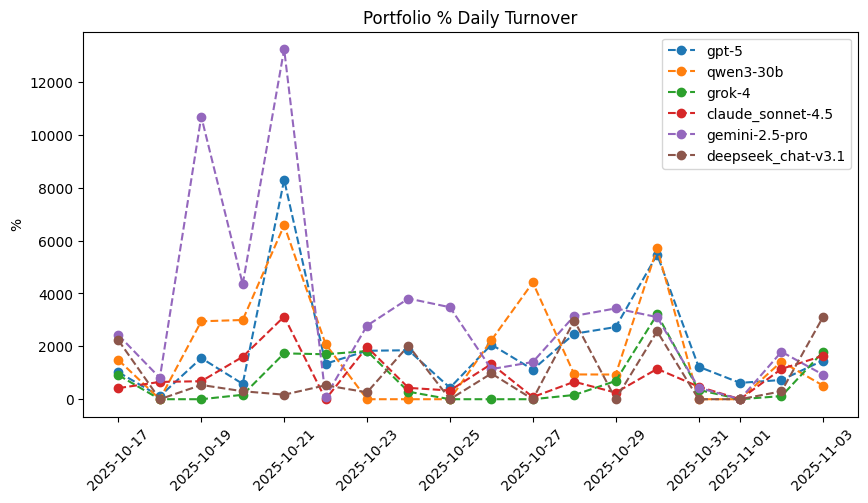

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for bot in bots:
    bot.plot_percent_daily_turnover(ax=ax)
plt.show()

In [7]:
fill_data = deepseek_bot.get_historical_fill_data()
print(fill_data.columns)
fill_data

Index(['coin', 'px', 'sz', 'side', 'startPosition', 'dir', 'closedPnl', 'hash',
       'oid', 'crossed', 'fee', 'tid', 'feeToken', 'twapId', 'liquidation',
       'cumPnl', 'nav', 'notional_trading_volume'],
      dtype='object')


,coin,px,sz,side,startPosition,dir,closedPnl,hash,oid,crossed,fee,tid,feeToken,twapId,liquidation,cumPnl,nav,notional_trading_volume
timestamp,,,,,,,,,,,,,,,,,,
2025-10-17 18:14:46.005,BTC,107146.00000,0.10059,A,0.0,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,4.850017,95788746437357,USDC,None,NaN,0.000000,10000.000000,10777.81614
2025-10-17 18:14:46.005,BTC,107146.00000,0.00011,A,-0.10059,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,0.005303,725690248891225,USDC,None,NaN,0.000000,10000.000000,11.78606
2025-10-17 18:14:46.005,BTC,107146.00000,0.10930,A,-0.1007,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,5.269976,135556538554213,USDC,None,NaN,0.000000,10000.000000,11711.05780
2025-10-17 18:43:13.714,BNB,1076.60000,8.36000,B,0.0,Open Long,0.0,0x965d5291652da22d97d7042dae1a8b02020300770020...,204624767080,True,4.050169,903777859081016,USDC,None,NaN,0.000000,10000.000000,9000.37600
2025-10-17 18:43:13.714,BNB,1076.60000,0.94000,B,8.36,Open Long,0.0,0x965d5291652da22d97d7042dae1a8b02020300770020...,204624767080,True,0.455401,82372982269813,USDC,None,NaN,0.000000,10000.000000,1012.00400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-03 18:25:57.270,DOGE,0.16640,14060.00000,B,2887.0,Open Long,0.0,0x5c16ae29d7771bd65d90042ec9891902022a000f727a...,221729020003,True,0.935833,149073805421165,USDC,None,NaN,1696.485041,11696.485041,2339.58400
2025-11-03 18:25:57.270,DOGE,0.16640,3063.00000,B,16947.0,Open Long,0.0,0x5c16ae29d7771bd65d90042ec9891902022a000f727a...,221729020003,True,0.203873,699041202304590,USDC,None,NaN,1696.485041,11696.485041,509.68320
2025-11-03 18:25:57.270,DOGE,0.16641,363.00000,B,20010.0,Open Long,0.0,0x5c16ae29d7771bd65d90042ec9891902022a000f727a...,221729020003,True,0.024162,990548103900254,USDC,None,NaN,1696.485041,11696.485041,60.40683


In [8]:
btc_prices = pd.read_csv(data_dir + 'BTC_USDT_1m_30d.csv')
btc_prices

,timestamp,open,high,low,close,volume
0,2025-09-29 22:35:00,114090.52,114090.52,114041.92,114041.93,3.23364
1,2025-09-29 22:36:00,114041.92,114041.93,114037.48,114037.48,3.52008
2,2025-09-29 22:37:00,114037.49,114037.49,114037.48,114037.49,1.31498
3,2025-09-29 22:38:00,114037.48,114037.49,114037.47,114037.48,2.78636
4,2025-09-29 22:39:00,114037.48,114037.48,114020.00,114020.00,12.38574
...,...,...,...,...,...,...
43196,2025-10-29 22:31:00,111182.01,111199.81,111150.01,111156.40,12.90429
43197,2025-10-29 22:32:00,111156.40,111210.60,111156.39,111210.59,4.09702
43198,2025-10-29 22:33:00,111210.59,111210.59,111170.48,111170.48,2.86821
43199,2025-10-29 22:34:00,111170.49,111180.15,111156.93,111156.94,1.32202


In [9]:
!pip install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 41.2 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: botocore
    Found existing installation: botocore 1.34.69
    Uninstalling botocore-1.34.69:
      Successfully uninstalled botocore-1.34.69
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.12.3 requires botocore<1.34.70,>=1.34.41, but you have botocore 1.40.65 which is incompatible.


In [12]:
def get_hyperliquid_history(coin: str, start_dt: datetime, end_dt: datetime = None):
    # convert to milliseconds
    start_ms = int(start_dt.timestamp() * 1000)
    end_ms = int(end_dt.timestamp() * 1000) if end_dt else None

    payload = {
        "type": "fundingHistory",
        "coin": coin,
        "startTime": start_ms
    }
    if end_ms is not None:
        payload["endTime"] = end_ms

    url = "https://api.hyperliquid.xyz/info"
    resp = requests.post(url, json=payload)
    resp.raise_for_status()
    data = resp.json()
    return data  # list of dicts with keys: coin, fundingRate, premium, time


coin = "BTC"
start_dt = datetime(2025, 10, 1)
end_dt   = datetime(2025, 10, 10)
history = get_hyperliquid_history(coin, start_dt, end_dt)
for rec in history:
    # convert time
    t = datetime.fromtimestamp(rec["time"] / 1000.0)
    print(f"{t} | fundingRate={rec['fundingRate']} | premium={rec['premium']}")

2025-10-01 00:00:00.054000 | fundingRate=0.0000125 | premium=-0.0001008392
2025-10-01 01:00:00.012000 | fundingRate=0.0000125 | premium=-0.000051898
2025-10-01 02:00:00.068000 | fundingRate=0.0000125 | premium=-0.0000634535
2025-10-01 03:00:00.008000 | fundingRate=0.0000125 | premium=-0.0000849831
2025-10-01 04:00:00.041000 | fundingRate=0.0000125 | premium=-0.000073454
2025-10-01 05:00:00.031000 | fundingRate=0.0000125 | premium=-0.0000168753
2025-10-01 06:00:00.020000 | fundingRate=0.0000125 | premium=0.0000273985
2025-10-01 07:00:00.030000 | fundingRate=0.0000125 | premium=0.0001572762
2025-10-01 08:00:00.021000 | fundingRate=0.0000125 | premium=0.0001213027
2025-10-01 09:00:00.045000 | fundingRate=0.0000125 | premium=0.0000148641
2025-10-01 10:00:00.081000 | fundingRate=0.0000125 | premium=-0.0000047901
2025-10-01 11:00:00.109000 | fundingRate=0.0000125 | premium=-0.0001091017
2025-10-01 12:00:00.038000 | fundingRate=0.0000125 | premium=-0.0002240777
2025-10-01 13:00:00.083000 | fu